<a href="https://colab.research.google.com/github/Bony-39/interpretable-credit-default/blob/main/interpretable_credit_default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpretable Credit Default Prediction

## Comparing Logistic Regression and Random Forest

### Research Questions

1. Can historical credit and repayment information predict default in the following month?
2. Does Random Forest outperform Logistic Regression?
3. Which features have the greatest influence on predicted default risk?

## Dataset

This project uses the Default of Credit Card Clients dataset from the UCI Machine Learning Repository. It contains 30,000 credit-card customer observations and 23 explanatory variables, including demographic characteristics, credit limits, historical repayment status, bill amounts and payment amounts.

The repayment records were collected from credit-card customers in Taiwan in 2005. The target variable indicates whether a customer defaulted in the following month.

Dataset: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

Original study: Yeh, I.-C., and Lien, C.-h. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. *Expert Systems with Applications, 36*(2), 2473–2480.

In [ ]:
!pip install -q ucimlrepo shap

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

credit_data = fetch_ucirepo(id=350)

X = credit_data.data.features.copy()
y = credit_data.data.targets.iloc[:, 0].astype(int)

X = X.drop(columns=["ID"], errors="ignore")

print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nColumn names:")
print(X.columns.tolist())

print("\nFirst five rows:")
display(X.head())

print("\nTarget distribution:")
display(y.value_counts())

print("\nTarget percentage:")
display(y.value_counts(normalize=True).round(4))

Feature matrix shape: (30000, 23)
Target shape: (30000,)

Column names:
['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23']

First five rows:


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679



Target distribution:


,count
Y,
0,23364
1,6636



Target percentage:


,proportion
Y,
0,0.7788
1,0.2212


In [ ]:
data_quality = pd.DataFrame({
    "Data Type": X.dtypes,
    "Missing Values": X.isnull().sum(),
    "Unique Values": X.nunique()
})

display(data_quality)

,Data Type,Missing Values,Unique Values
X1,int64,0,81
X2,int64,0,2
X3,int64,0,7
X4,int64,0,4
X5,int64,0,56
X6,int64,0,11
X7,int64,0,11
X8,int64,0,11
X9,int64,0,11
X10,int64,0,10


In [ ]:
column_mapping = {
    "SEX": "X2",
    "EDUCATION": "X3",
    "MARRIAGE": "X4",
    "PAY_0": "X6"
}

for display_name, col_name in column_mapping.items():
    print(f"\n{display_name}:")
    print(X[col_name].value_counts().sort_index())


SEX:
X2
1    11888
2    18112
Name: count, dtype: int64

EDUCATION:
X3
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE:
X4
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

PAY_0:
X6
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64


### Initial Data Inspection

- The dataset contains 30,000 customer records.
- It includes 23 explanatory variables.
- Approximately 22% of customers defaulted in the following month.
- No missing values were identified.
- The target variable is moderately imbalanced.
- Several categorical variables contain codes that require further examination.

In [ ]:
raw_data = pd.concat([X, y.rename("DEFAULT")], axis=1)

duplicate_count = raw_data.duplicated().sum()

print("Duplicated records:", duplicate_count)

Duplicated records: 35


In [ ]:
column_names = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

X.columns = column_names
y.name = "DEFAULT"

print(X.columns.tolist())
display(X.head())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [ ]:
X["EDUCATION"] = X["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

X["MARRIAGE"] = X["MARRIAGE"].replace({
    0: 3
})

print("EDUCATION after recoding:")
print(X["EDUCATION"].value_counts().sort_index())

print("\nMARRIAGE after recoding:")
print(X["MARRIAGE"].value_counts().sort_index())

EDUCATION after recoding:
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE after recoding:
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


### Data Preprocessing Decisions

- The original feature names X1–X23 were replaced with descriptive variable names based on the UCI data dictionary.
- Undefined education codes 0, 5 and 6 were grouped into the “Other/Unknown” category.
- Undefined marital-status code 0 was grouped into the “Other/Unknown” category.
- Historical repayment-status variables were retained as ordinal numerical features.
- Duplicate observations were inspected but were not automatically removed because identical feature values do not necessarily indicate duplicate customers.

## Exploratory Data Analysis

This section examines the target distribution and explores the relationships between selected customer characteristics and credit default.

In [ ]:
import os

os.makedirs("figures", exist_ok=True)

analysis_df = X.copy()
analysis_df["DEFAULT"] = y

analysis_df["DEFAULT_LABEL"] = analysis_df["DEFAULT"].map({
    0: "No Default",
    1: "Default"
})

print(analysis_df.shape)
display(analysis_df.head())

(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT,DEFAULT_LABEL
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,689,0,0,0,0,1,Default
1,120000,2,2,2,26,-1,2,0,0,0,...,3455,3261,0,1000,1000,1000,0,2000,1,Default
2,90000,2,2,2,34,0,0,0,0,0,...,14948,15549,1518,1500,1000,1000,1000,5000,0,No Default
3,50000,2,2,1,37,0,0,0,0,0,...,28959,29547,2000,2019,1200,1100,1069,1000,0,No Default
4,50000,1,2,1,57,-1,0,-1,0,0,...,19146,19131,2000,36681,10000,9000,689,679,0,No Default


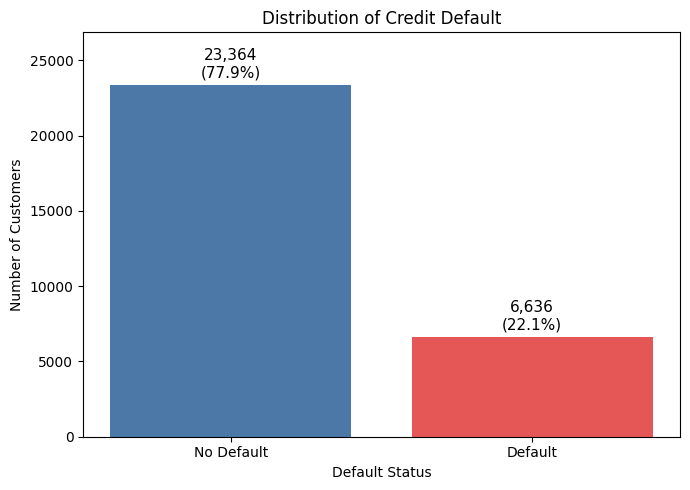

In [ ]:
target_counts = (
    analysis_df["DEFAULT_LABEL"]
    .value_counts()
    .reindex(["No Default", "Default"])
)

target_percentages = target_counts / target_counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    target_counts.index,
    target_counts.values,
    color=["#4C78A8", "#E45756"]
)

for bar, count, percentage in zip(
    bars,
    target_counts.values,
    target_percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 300,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Distribution of Credit Default")
ax.set_xlabel("Default Status")
ax.set_ylabel("Number of Customers")
ax.set_ylim(0, target_counts.max() * 1.15)

plt.tight_layout()
plt.savefig(
    "figures/01_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Target Distribution

The dataset contains 23,364 non-default observations and 6,636 default observations. Default cases represent approximately 22.1% of the sample, indicating moderate class imbalance. Therefore, model performance should not be evaluated using accuracy alone. ROC-AUC, recall and F1-score will also be considered.

In [ ]:
pay0_summary = (
    analysis_df
    .groupby("PAY_0")
    .agg(
        Customer_Count=("DEFAULT", "size"),
        Default_Rate=("DEFAULT", "mean")
    )
    .reset_index()
)

pay0_summary["Default_Rate_Percent"] = (
    pay0_summary["Default_Rate"] * 100
)

display(pay0_summary)

,PAY_0,Customer_Count,Default_Rate,Default_Rate_Percent
0,-2,2759,0.132294,13.229431
1,-1,5686,0.167781,16.778051
2,0,14737,0.128113,12.811291
3,1,3688,0.339479,33.947939
4,2,2667,0.691414,69.141357
5,3,322,0.757764,75.776398
6,4,76,0.684211,68.421053
7,5,26,0.500000,50.000000
8,6,11,0.545455,54.545455
9,7,9,0.777778,77.777778


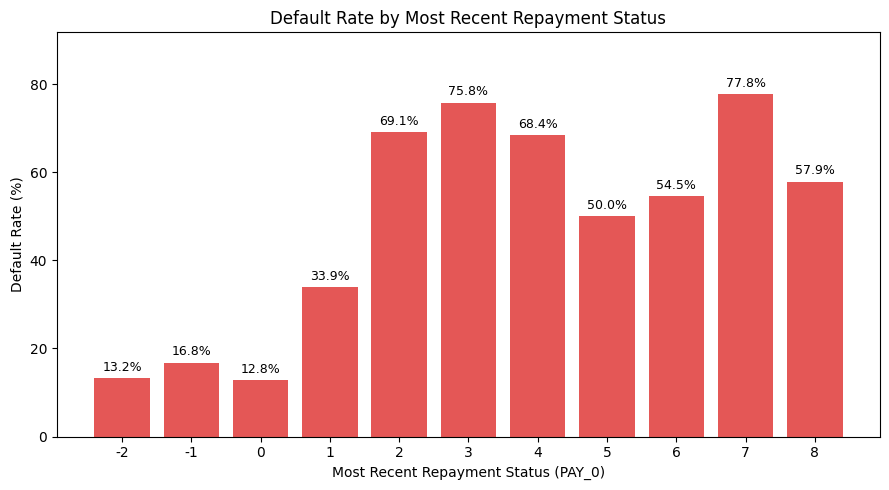

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    pay0_summary["PAY_0"].astype(str),
    pay0_summary["Default_Rate_Percent"],
    color="#E45756"
)

ax.set_title("Default Rate by Most Recent Repayment Status")
ax.set_xlabel("Most Recent Repayment Status (PAY_0)")
ax.set_ylabel("Default Rate (%)")

for bar, rate in zip(
    bars,
    pay0_summary["Default_Rate_Percent"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylim(
    0,
    pay0_summary["Default_Rate_Percent"].max() * 1.18
)

plt.tight_layout()
plt.savefig(
    "figures/02_default_rate_by_payment_status.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Repayment Status and Default Risk

The default rate increased substantially as the most recent repayment delay became more severe. Customers with PAY_0 = 0 had a default rate of approximately 12.8%, compared with 33.9% for a one-month delay, 69.1% for a two-month delay and 75.8% for a three-month delay. This indicates a strong association between recent repayment behavior and subsequent default.

However, categories representing delays of four months or more contained relatively few observations. Their default rates were therefore more volatile and should not be interpreted as a stable monotonic pattern. These results describe predictive associations rather than causal effects.

In [ ]:
credit_summary = (
    analysis_df
    .groupby("DEFAULT_LABEL")["LIMIT_BAL"]
    .agg(["count", "mean", "median", "std"])
    .reindex(["No Default", "Default"])
)

display(credit_summary.round(2))

,count,mean,median,std
DEFAULT_LABEL,,,,
No Default,23364,178099.73,150000.0,131628.36
Default,6636,130109.66,90000.0,115378.54


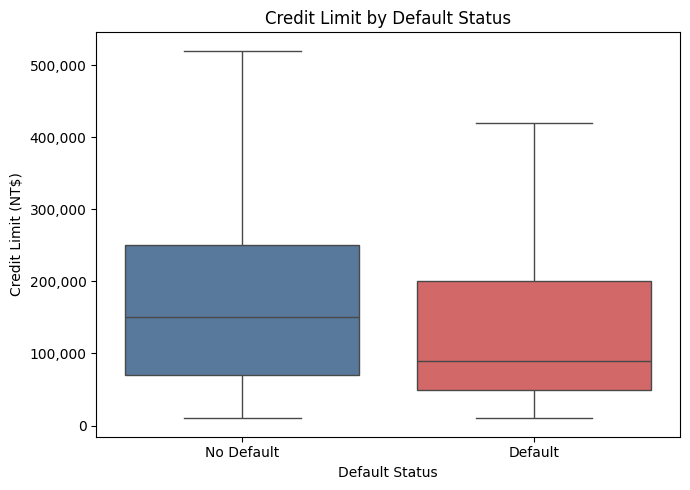

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=analysis_df,
    x="DEFAULT_LABEL",
    y="LIMIT_BAL",
    order=["No Default", "Default"],
    hue="DEFAULT_LABEL",
    palette={
        "No Default": "#4C78A8",
        "Default": "#E45756"
    },
    legend=False,
    showfliers=False,
    ax=ax
)

ax.set_title("Credit Limit by Default Status")
ax.set_xlabel("Default Status")
ax.set_ylabel("Credit Limit (NT$)")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, position: f"{value:,.0f}")
)

plt.tight_layout()
plt.savefig(
    "figures/03_credit_limit_by_default_status.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Predictive Modeling

Non-defaulting customers had a higher mean credit limit of approximately NTD 178,100 and a median of NTD 150,000. Defaulting customers had a lower mean credit limit of approximately NTD 130,110 and a median of NTD 90,000.

Two classification models were developed: Logistic Regression as an interpretable linear baseline and Random Forest as a nonlinear ensemble model. The models were evaluated on the same stratified holdout test set.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training features:", X_train.shape)
print("Test features:", X_test.shape)

split_summary = pd.DataFrame({
    "Training Set": y_train.value_counts(normalize=True),
    "Test Set": y_test.value_counts(normalize=True)
})

display(split_summary.round(4))

Training features: (24000, 23)
Test features: (6000, 23)


,Training Set,Test Set
DEFAULT,,
0,0.7788,0.7788
1,0.2212,0.2212


### Train-Test Split

The dataset was divided into an 80% training set and a 20% test set. Stratified sampling was used to preserve the original default proportion in both subsets. A fixed random seed of 42 was applied to ensure reproducibility.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

numeric_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumeric and ordinal features:")
print(numeric_features)

Categorical features:
['SEX', 'EDUCATION', 'MARRIAGE']

Numeric and ordinal features:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [ ]:
linear_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_features
    ),
    (
        "numeric",
        StandardScaler(),
        numeric_features
    )
])

In [ ]:
tree_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_features
    ),
    (
        "numeric",
        "passthrough",
        numeric_features
    )
])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logistic_model = Pipeline([
    ("preprocess", linear_preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

random_forest_model = Pipeline([
    ("preprocess", tree_preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [ ]:
logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("Both models were trained successfully.")

Both models were trained successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model
}

results = []
prediction_results = {}

for model_name, model in models.items():

    predicted_class = model.predict(X_test)
    predicted_probability = model.predict_proba(X_test)[:, 1]

    prediction_results[model_name] = {
        "class": predicted_class,
        "probability": predicted_probability
    }

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predicted_class
        ),
        "Precision": precision_score(
            y_test,
            predicted_class,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predicted_class
        ),
        "F1-Score": f1_score(
            y_test,
            predicted_class
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            predicted_probability
        )
    })

results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")

display(results_df.round(4))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.6788,0.3681,0.6307,0.4649,0.7104
Random Forest,0.7832,0.5085,0.5870,0.5449,0.7754


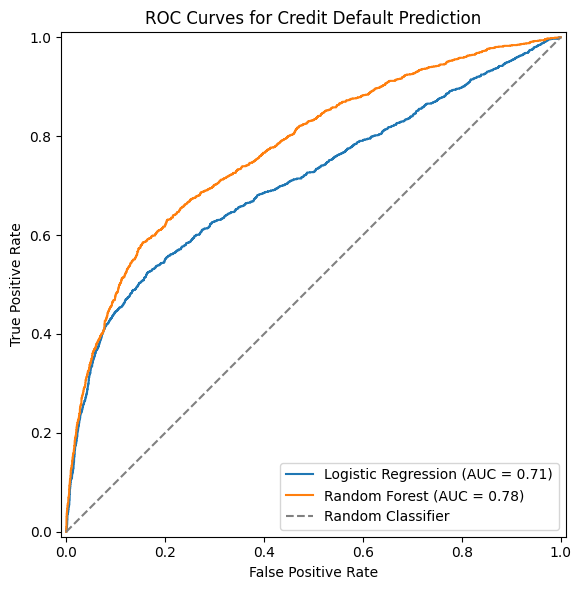

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7, 6))

for model_name in models:

    RocCurveDisplay.from_predictions(
        y_test,
        prediction_results[model_name]["probability"],
        name=model_name,
        ax=ax
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

ax.set_title("ROC Curves for Credit Default Prediction")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()

plt.tight_layout()
plt.savefig(
    "figures/04_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

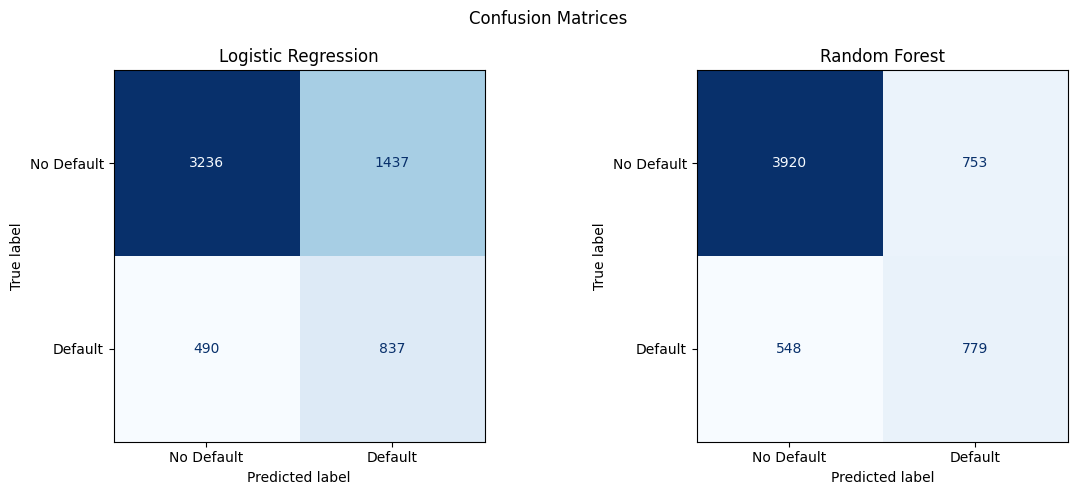

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

for ax, model_name in zip(axes, models):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction_results[model_name]["class"],
        display_labels=["No Default", "Default"],
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(model_name)

plt.suptitle("Confusion Matrices")
plt.tight_layout()

plt.savefig(
    "figures/05_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Model Performance Comparison

Random Forest achieved a higher ROC-AUC of 0.7754, compared with 0.7104 for Logistic Regression, indicating stronger overall discrimination between defaulting and non-defaulting customers. Random Forest also produced higher precision and F1-score.

Logistic Regression achieved a higher recall of 0.6307 and missed 490 default cases, whereas Random Forest achieved a recall of 0.5870 and missed 548 default cases. However, Logistic Regression generated 1,437 false-positive predictions, compared with 753 for Random Forest.

Random Forest was therefore selected as the primary model because it provided a better overall balance between discrimination, precision and recall. Nevertheless, the preferred classification threshold may depend on the relative costs of false-positive and false-negative decisions.

## Explainable AI Analysis

SHAP was applied to the Random Forest model to examine both global feature importance and individual-level predictions. SHAP values describe how each feature influences the model output; they do not establish causal relationships.

In [ ]:
import shap

rf_preprocessor = random_forest_model.named_steps["preprocess"]
rf_estimator = random_forest_model.named_steps["model"]

X_train_transformed = rf_preprocessor.transform(X_train)
X_test_transformed = rf_preprocessor.transform(X_test)

feature_names = rf_preprocessor.get_feature_names_out()

clean_feature_names = [
    name.replace("categorical__", "")
        .replace("numeric__", "")
    for name in feature_names
]

X_train_rf = pd.DataFrame(
    X_train_transformed,
    columns=clean_feature_names,
    index=X_train.index
)

X_test_rf = pd.DataFrame(
    X_test_transformed,
    columns=clean_feature_names,
    index=X_test.index
)

print("Transformed training data:", X_train_rf.shape)
print("Transformed test data:", X_test_rf.shape)
print("\nTransformed feature names:")
print(clean_feature_names)

Transformed training data: (24000, 29)
Transformed test data: (6000, 29)

Transformed feature names:
['SEX_1', 'SEX_2', 'EDUCATION_1', 'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3', 'LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [ ]:
X_shap_sample = X_test_rf.sample(
    n=500,
    random_state=42
)

explainer = shap.TreeExplainer(rf_estimator)

shap_output = explainer(X_shap_sample)

print("SHAP value shape:", shap_output.values.shape)
print("Model classes:", rf_estimator.classes_)

SHAP value shape: (500, 29, 2)
Model classes: [0 1]


In [ ]:
if shap_output.values.ndim == 3:
    shap_default = shap_output[:, :, 1]
elif shap_output.values.ndim == 2:
    shap_default = shap_output
else:
    raise ValueError(
        f"Unexpected SHAP shape: {shap_output.values.shape}"
    )

print("Default-class SHAP shape:", shap_default.values.shape)

Default-class SHAP shape: (500, 29)


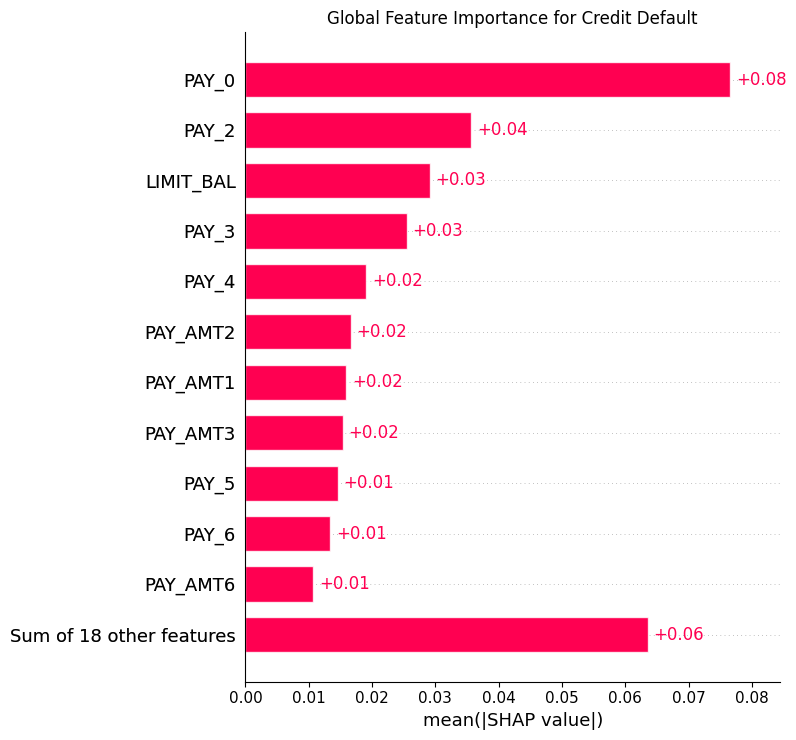

In [ ]:
shap.plots.bar(
    shap_default,
    max_display=12,
    show=False
)

plt.title("Global Feature Importance for Credit Default")
plt.tight_layout()

plt.savefig(
    "figures/06_shap_global_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

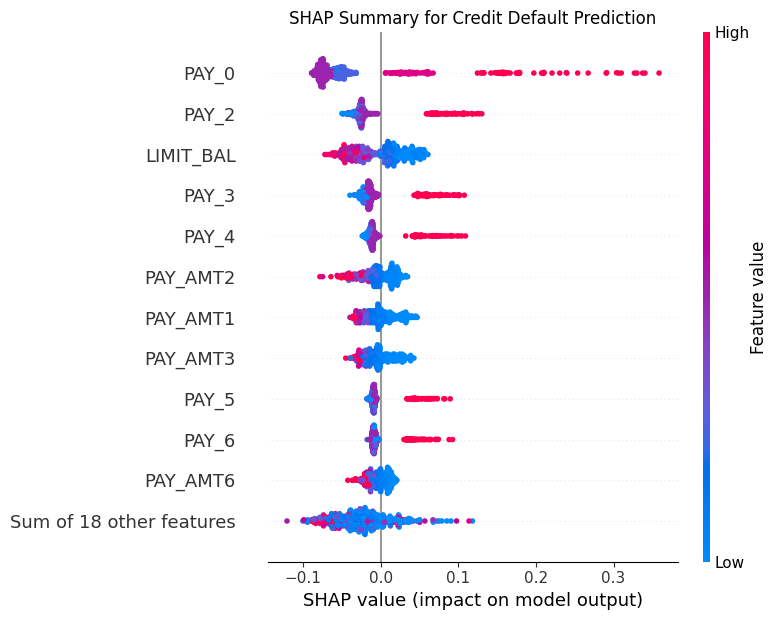

In [ ]:
shap.plots.beeswarm(
    shap_default,
    max_display=12,
    show=False
)

plt.title("SHAP Summary for Credit Default Prediction")
plt.tight_layout()

plt.savefig(
    "figures/07_shap_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Global SHAP Interpretation

The SHAP analysis identified recent repayment status as the most influential group of predictors. PAY_0 had the largest mean absolute SHAP value, followed by PAY_2, LIMIT_BAL and other historical repayment-status variables.

Higher values of PAY_0, PAY_2, PAY_3 and PAY_4 generally pushed the model output toward default, indicating that more severe recent repayment delays were strongly associated with higher predicted default risk. This finding was consistent with the exploratory analysis, in which default rates increased sharply among customers with recent payment delays.

Higher credit limits generally pushed the model output toward non-default, whereas lower credit limits were associated with higher model-estimated risk. Higher recent payment amounts also tended to reduce the predicted risk. These patterns represent relationships learned by the Random Forest model and should not be interpreted as causal effects.

In [ ]:
rf_case_results = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": prediction_results["Random Forest"]["class"],
    "Risk_Score": prediction_results["Random Forest"]["probability"]
}, index=X_test.index)

correct_defaults = rf_case_results[
    (rf_case_results["Actual"] == 1) &
    (rf_case_results["Predicted"] == 1)
].copy()

median_risk = correct_defaults["Risk_Score"].median()

selected_index = (
    correct_defaults["Risk_Score"] - median_risk
).abs().idxmin()

print("Selected customer index:", selected_index)
display(rf_case_results.loc[[selected_index]])

Selected customer index: 12039


,Actual,Predicted,Risk_Score
12039,1,1,0.773171


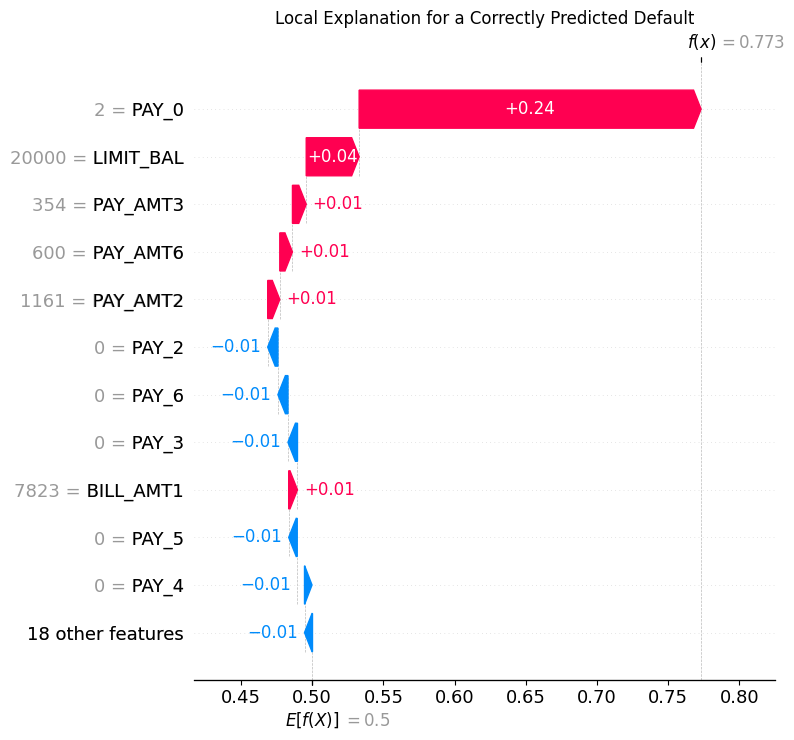

In [ ]:
selected_customer = X_test_rf.loc[[selected_index]]

local_shap_output = explainer(selected_customer)

if local_shap_output.values.ndim == 3:
    local_default_shap = local_shap_output[:, :, 1]
else:
    local_default_shap = local_shap_output

shap.plots.waterfall(
    local_default_shap[0],
    max_display=12,
    show=False
)

plt.title("Local Explanation for a Correctly Predicted Default")
plt.tight_layout()

plt.savefig(
    "figures/08_shap_local_waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Local SHAP Interpretation

The selected observation was an actual default case that was correctly classified by the Random Forest model. Its model-estimated risk score was approximately 0.773.

A most recent repayment status of PAY_0 = 2 was the dominant contributor, increasing the model output by approximately 0.24. The relatively low credit limit of NTD 20,000 also increased the predicted risk. Low recent payment amounts provided additional smaller positive contributions.

Some earlier repayment-status variables, including PAY_2, PAY_3 and PAY_6, slightly reduced the predicted risk. However, these protective contributions were not sufficient to offset the strong effect of the most recent two-month payment delay. This explanation describes the model's reasoning for one observation and does not imply that these factors caused the default.

## Robustness Check

Five-fold stratified cross-validation was conducted on the training set to assess whether model performance was stable across different data subsets. The holdout test set remained untouched during this procedure.

In [ ]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_summary = []

for model_name, model in models.items():

    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1
    )

    cv_summary.append({
        "Model": model_name,
        "ROC-AUC Mean": cv_scores["test_roc_auc"].mean(),
        "ROC-AUC SD": cv_scores["test_roc_auc"].std(),
        "Precision Mean": cv_scores["test_precision"].mean(),
        "Recall Mean": cv_scores["test_recall"].mean(),
        "F1 Mean": cv_scores["test_f1"].mean()
    })

cv_summary_df = pd.DataFrame(cv_summary)
cv_summary_df = cv_summary_df.set_index("Model")

display(cv_summary_df.round(4))

,ROC-AUC Mean,ROC-AUC SD,Precision Mean,Recall Mean,F1 Mean
Model,,,,,
Logistic Regression,0.7275,0.0113,0.3817,0.6506,0.4811
Random Forest,0.7822,0.0053,0.5096,0.5815,0.5431


### Cross-Validation Results

Five-fold cross-validation supported the holdout-set findings. Random Forest achieved a mean ROC-AUC of 0.7822 with a standard deviation of 0.0053, compared with 0.7275 ± 0.0113 for Logistic Regression. Random Forest also produced a higher mean F1-score of 0.5431, while Logistic Regression maintained a higher mean recall of 0.6506.

The relatively small cross-validation standard deviations indicate that model performance was reasonably stable across different training subsets. These results reinforce the selection of Random Forest as the primary model, while preserving the previously identified trade-off between overall discrimination and default-case recall.

## Limitations

1. The dataset reflects credit-card customers from Taiwan and contains repayment records from 2005. The findings may not generalize directly to current customers or other financial markets.

2. The Random Forest model used class weighting to address class imbalance. Its output should be interpreted as a model risk score rather than a calibrated real-world probability of default.

3. Several demographic variables contained undefined category codes that were grouped into an “Other/Unknown” category, which may have reduced information granularity.

4. SHAP explains how the trained model uses the available features but does not establish causal relationships between customer characteristics and default.

5. Several repayment and billing variables are correlated. SHAP importance may therefore be distributed across related features rather than attributed to a single variable.

6. Sensitive attributes such as sex and age were included in the dataset. A real credit-decision system would require additional fairness, legal and ethical assessment before deployment.

7. The models were developed for educational and exploratory purposes and should not be used directly for real credit decisions.
8. The model hyperparameters were selected as reasonable baseline settings rather than optimized through systematic or nested cross-validation. More extensive tuning may improve predictive performance but was outside the scope of this short exploratory project.

## Conclusion

This project examined whether historical credit and repayment information could be used to predict credit-card default and whether a nonlinear Random Forest model outperformed an interpretable Logistic Regression baseline.

Random Forest achieved a higher holdout ROC-AUC of 0.7754 and F1-score of 0.5449, compared with 0.7104 and 0.4649 for Logistic Regression. It also substantially reduced false-positive predictions, although Logistic Regression identified a slightly higher proportion of actual default cases.Five-fold cross-validation produced a mean ROC-AUC of 0.7822 ± 0.0053 for Random Forest, supporting the stability of the holdout-set result.

SHAP analysis showed that recent repayment status, particularly PAY_0 and PAY_2, was the most influential source of predictive information. Credit limit and recent payment amounts also contributed to the model predictions. For the selected correctly classified default case, a two-month recent payment delay was the dominant factor pushing the model output toward default.

Overall, the results demonstrate that historical repayment behavior provides meaningful predictive information and that explainable machine-learning methods can improve the transparency of nonlinear credit-risk models. However, the model provides moderate rather than perfect discrimination and requires further validation, calibration and fairness assessment before any practical application.

In [1]:
!zip -r figures.zip figures

from google.colab import files
files.download("figures.zip")

	zip warning: name not matched: figures

zip error: Nothing to do! (try: zip -r figures.zip . -i figures)


FileNotFoundError: Cannot find file: figures.zip